# Tiền xử lý & Trích xuất đặc trưng đa miền
- Bước 1: Chuẩn bị dữ liệu thật + Build manifest -->  sanity check
- Bước 2: Chốt dải Bandpass cho Square-Law Demodulation
- Bước 3: Trích xuất bể đặc trưng đầy đủ
- Bước 4: Xác nhận phân phối đặc trưng và chuẩn bị cho Giai đoạn 2

In [1]:
USE_SYNTHETIC_DATA = False
DATA_ROOT = "../../data/raw"        # trỏ vào thư mục chứa dữ liệu CWRU thật
OUTPUT_DIR = "outputs"

from common.pipeline import get_manifest

manifest = get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=DATA_ROOT,
    synthetic_data_root=None,
    output_dir=OUTPUT_DIR,
)   


In [17]:
# Lọc manifest theo phạm vi đã chốt
import pandas as pd

manifest = pd.read_csv("outputs/tables/manifest.csv")

# (1) Chỉ 12k Drive-End
mask_category = (
    (manifest["source_category"] == "12k_Drive_End_Bearing_Fault_Data")
    | (manifest["label"] == "Normal")
)
manifest = manifest[mask_category]

# (2) OR chỉ Centered (@6)
mask_or = (manifest["label"] != "OR") | (manifest["or_position"] == "Centered")
manifest = manifest[mask_or]

# (3) Bỏ đường kính NTN (28, 40) — Normal có NaN diameter nên giữ lại
valid_diams = {7, 14, 21}
mask_diam = (
    manifest["fault_diameter_mils"].isna()
    | manifest["fault_diameter_mils"].isin(valid_diams)
)
manifest = manifest[mask_diam]

print(f"Số file sau lọc: {len(manifest)}")
print(manifest.groupby(["label", "load_hp"]).size().unstack(fill_value=0))

Số file sau lọc: 40
load_hp  0  1  2  3
label              
B        3  3  3  3
IR       3  3  3  3
Normal   1  1  1  1
OR       3  3  3  3


- Santity check

In [18]:
from common.io_utils import run_sanity_checks, build_manifest, inspect_mat_file
from pathlib import Path

# Build manifest thô (chưa cache) để inspect từng file
manifest_raw = build_manifest(Path(DATA_ROOT))

# Thêm cột n_samples_DE, rpm_from_file...
for i, row in manifest_raw.iterrows():
    info = inspect_mat_file(Path(row["file_path"]))
    for k, v in info.items():
        manifest_raw.at[i, k] = v

# Chạy sanity checks
manifest_checked = run_sanity_checks(manifest_raw)

# Xem các file có cảnh báo
warnings_col = manifest_checked["warnings"]
flagged = manifest_checked[warnings_col.apply(lambda w: len(w) > 0)]
print(f"Files có cảnh báo: {len(flagged)}/{len(manifest_checked)}")
for _, row in flagged.iterrows():
    print(f"  {row['file_path']}: {row['warnings']}")

Files có cảnh báo: 125/161
  ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\028\3005_0.mat: VONG_BI_NTN: đường kính 28 mils dùng vòng bi NTN, KHÔNG dùng hình học SKF 6205 để tính BPFO/BPFI/BSF.
  ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\028\3006_1.mat: VONG_BI_NTN: đường kính 28 mils dùng vòng bi NTN, KHÔNG dùng hình học SKF 6205 để tính BPFO/BPFI/BSF.
  ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\028\3007_2.mat: VONG_BI_NTN: đường kính 28 mils dùng vòng bi NTN, KHÔNG dùng hình học SKF 6205 để tính BPFO/BPFI/BSF.
  ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\028\3008_3.mat: VONG_BI_NTN: đường kính 28 mils dùng vòng bi NTN, KHÔNG dùng hình học SKF 6205 để tính BPFO/BPFI/BSF.
  ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\IR\028\3001_0.mat: VONG_BI_NTN: đường kính 28 mils dùng vòng bi NTN, KHÔNG dùng hình học SKF 6205 để tính BPFO/BPFI/BSF.
  ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\IR\028\3002_1.mat: VONG_BI_NTN: đường kính 28 mils dùng vòng bi NTN, KHÔ

- Chốt dải Bandpass cho Square-Law Demodulation

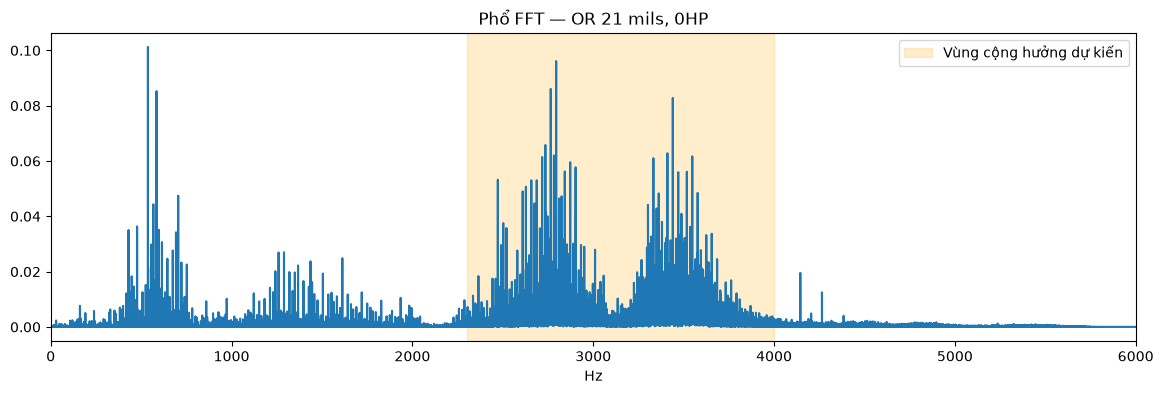

In [34]:
# notebooks/giai_doan_1/02_choose_bandpass.ipynb
from common.pipeline import pick_file
from common.io_utils import load_de_signal
from common.dsp import compute_fft
import matplotlib.pyplot as plt


# Chọn 1 file OR lỗi rõ (diam 21 mils, tải 0HP) để quan sát
file_path = pick_file(manifest, label="OR", load_hp=0, diameter_mils=21)
x = load_de_signal(Path(file_path))
fs = 12000

freqs, mag = compute_fft(x, fs)

plt.figure(figsize=(14, 4))
plt.plot(freqs, mag)
plt.xlabel("Hz")
plt.xlim(0, 6000)
plt.title("Phổ FFT — OR 21 mils, 0HP")

plt.axvspan(2300, 4000, alpha=0.2, color='orange', label='Vùng cộng hưởng dự kiến')
plt.legend()

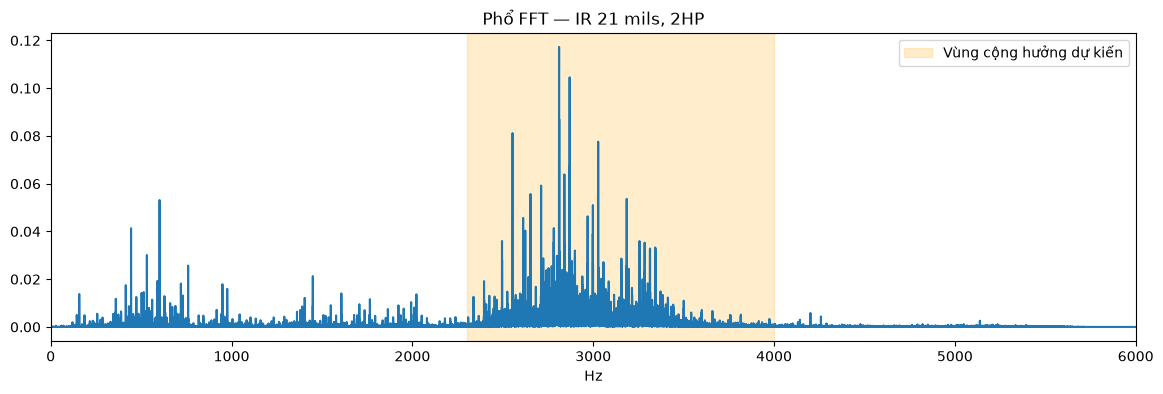

In [ ]:

# Chọn 1 file IR lỗi rõ (diam 21 mils, tải 0HP) để quan sát
file_path = pick_file(manifest, label="IR", load_hp=0, diameter_mils=21)
x = load_de_signal(Path(file_path))
fs = 12000

freqs, mag = compute_fft(x, fs)

plt.figure(figsize=(14, 4))
plt.plot(freqs, mag)
plt.xlabel("Hz")
plt.xlim(0, 6000)
plt.title("Phổ FFT — IR 21 mils, 0HP")

plt.axvspan(2300, 4000, alpha=0.2, color='orange', label='Vùng cộng hưởng dự kiến')
plt.legend()

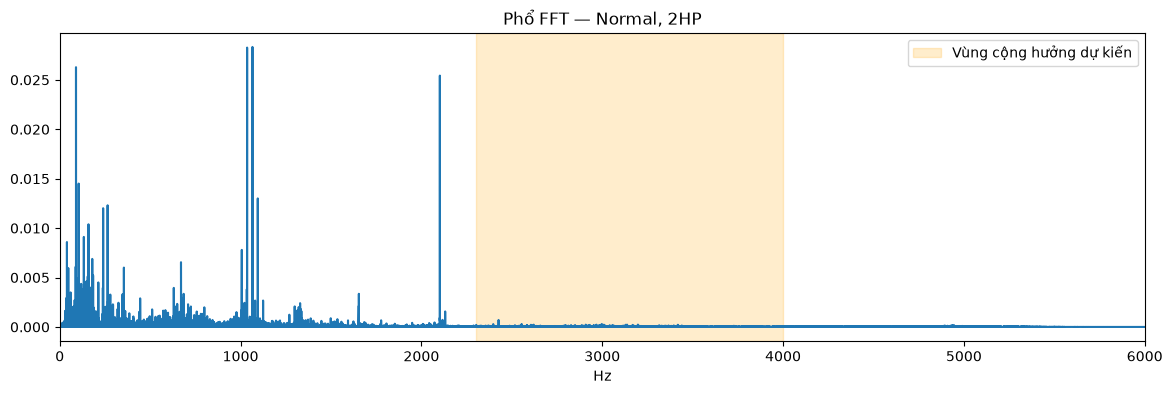

In [46]:
file_path = pick_file(manifest, label="Normal", load_hp=1)
x = load_de_signal(Path(file_path))
fs = 12000

freqs, mag = compute_fft(x, fs)

plt.figure(figsize=(14, 4))
plt.plot(freqs, mag)
plt.xlabel("Hz")
plt.xlim(0, 6000)
plt.title("Phổ FFT — Normal, 2HP")

plt.axvspan(2300, 4000, alpha=0.2, color='orange', label='Vùng cộng hưởng dự kiến')
plt.legend()

Text(0.5, 1.0, 'Phổ Envelope — Kiểm tra đỉnh BPFO/BPFI/BSF')

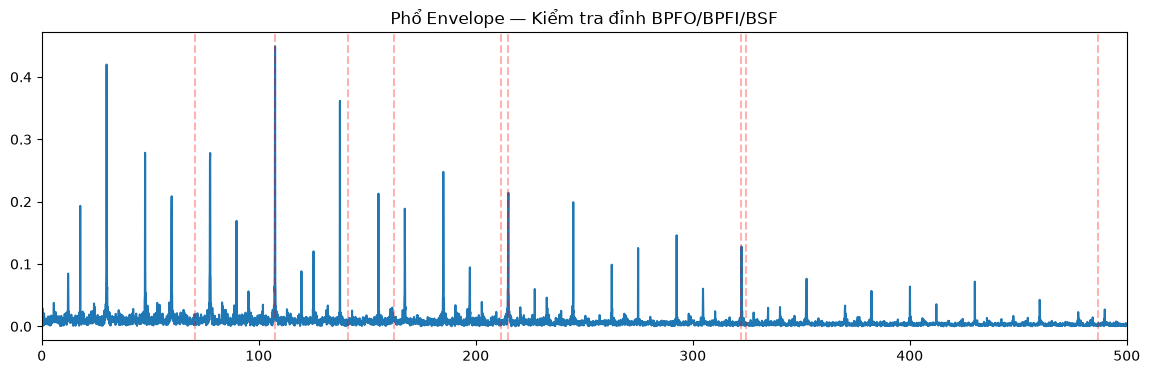

In [35]:
from common.dsp import square_law_envelope
from common.config import bearing_fault_frequencies, NOMINAL_RPM_BY_LOAD

BAND_HZ = (2300, 4000)   # ← điều chỉnh sau khi quan sát
rpm = NOMINAL_RPM_BY_LOAD[0]
fault_freqs = bearing_fault_frequencies(rpm)

env = square_law_envelope(x, fs, band=BAND_HZ, lp_cutoff=500)
freqs_env, mag_env = compute_fft(env - env.mean(), fs)

plt.figure(figsize=(14, 4))
plt.plot(freqs_env, mag_env)
for name in ["BPFO", "BPFI", "BSF"]:
    for h in [1, 2, 3]:
        plt.axvline(fault_freqs[name] * h, color='red', alpha=0.3, linestyle='--')
plt.xlim(0, 500)
plt.title("Phổ Envelope — Kiểm tra đỉnh BPFO/BPFI/BSF")

- Trích xuất bể đặc trưng đầy đủ

In [36]:
# notebooks/giai_doan_1/03_build_feature_table.ipynb
from common.features_full import build_full_feature_table
from common.io_utils import load_de_signal

BAND_HZ = (2300, 4000)  # ← giá trị đã chốt ở bước 2

feature_df = build_full_feature_table(
    manifest_df=manifest,       # manifest đã lọc sạch
    band_hz=BAND_HZ,
    load_de_signal_fn=load_de_signal,
)

print(f"Feature table: {feature_df.shape[0]} files × {feature_df.shape[1]} cột")
print(f"Số đặc trưng: {feature_df.shape[1] - 4}")  # trừ file_id, label, load_hp, fault_diameter_mils
print(f"Các cột: {list(feature_df.columns)}")

# Lưu lại
feature_df.to_csv("outputs/tables/feature_table_full.csv", index=False)

feature_df.head()

Feature table: 40 files × 36 cột
Số đặc trưng: 32
Các cột: ['file_id', 'label', 'load_hp', 'fault_diameter_mils', 'time_mean', 'time_std', 'time_rms', 'time_peak', 'time_kurtosis', 'time_skewness', 'time_variance', 'time_crest_factor', 'time_shape_factor', 'time_impulse_factor', 'time_margin_factor', 'order_f_rot_h1', 'order_f_rot_h2', 'order_f_rot_h3', 'order_BPFO_h1', 'order_BPFO_h2', 'order_BPFO_h3', 'order_BPFI_h1', 'order_BPFI_h2', 'order_BPFI_h3', 'order_BSF_h1', 'order_BSF_h2', 'order_BSF_h3', 'envelope_BPFO_h1', 'envelope_BPFO_h2', 'envelope_BPFO_h3', 'envelope_BPFI_h1', 'envelope_BPFI_h2', 'envelope_BPFI_h3', 'envelope_BSF_h1', 'envelope_BSF_h2', 'envelope_BSF_h3']


,file_id,label,load_hp,fault_diameter_mils,time_mean,time_std,time_rms,time_peak,time_kurtosis,time_skewness,...,order_BSF_h3,envelope_BPFO_h1,envelope_BPFO_h2,envelope_BPFO_h3,envelope_BPFI_h1,envelope_BPFI_h2,envelope_BPFI_h3,envelope_BSF_h1,envelope_BSF_h2,envelope_BSF_h3
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Dat...,B,0,7.0,0.012607,0.138662,0.139234,0.607020,-0.015284,-0.008854,...,0.000116,0.001951,0.003907,0.000810,0.002327,0.000810,0.000578,0.003208,0.000681,0.000861
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Dat...,B,1,7.0,0.003892,0.139014,0.139068,0.659649,-0.036246,0.007453,...,0.000062,0.003324,0.003019,0.000579,0.003094,0.000579,0.000901,0.001954,0.000441,0.000607
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Dat...,B,2,7.0,0.004564,0.147181,0.147252,0.604584,-0.168587,0.027124,...,0.000083,0.004001,0.001747,0.000770,0.003650,0.000770,0.001304,0.002377,0.000501,0.000659
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Dat...,B,3,7.0,0.004200,0.153577,0.153635,0.720562,-0.110270,0.020412,...,0.000101,0.001974,0.002506,0.001481,0.003463,0.000418,0.000259,0.001581,0.000983,0.000474
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Dat...,B,0,14.0,0.004688,0.152642,0.152714,2.278153,14.769217,0.225132,...,0.000476,0.002752,0.002129,0.001200,0.002025,0.001200,0.000725,0.002988,0.004423,0.001939


In [37]:
# Kiểm tra nhanh: mỗi nhóm đặc trưng có phân phối thế nào?
time_cols = [c for c in feature_df.columns if c.startswith("time_")]
order_cols = [c for c in feature_df.columns if c.startswith("order_")]
env_cols = [c for c in feature_df.columns if c.startswith("envelope_")]

print(f"Nhóm A (time):    {len(time_cols)} đặc trưng")
print(f"Nhóm B (order):   {len(order_cols)} đặc trưng")
print(f"Nhóm C (envelope): {len(env_cols)} đặc trưng")

# Kiểm tra phân phối label
print(f"\nPhân phối nhãn:\n{feature_df['label'].value_counts()}")
print(f"\nPhân phối tải:\n{feature_df['load_hp'].value_counts()}")

Nhóm A (time):    11 đặc trưng
Nhóm B (order):   12 đặc trưng
Nhóm C (envelope): 9 đặc trưng

Phân phối nhãn:
label
B         12
IR        12
OR        12
Normal     4
Name: count, dtype: int64

Phân phối tải:
load_hp
0    10
1    10
2    10
3    10
Name: count, dtype: int64


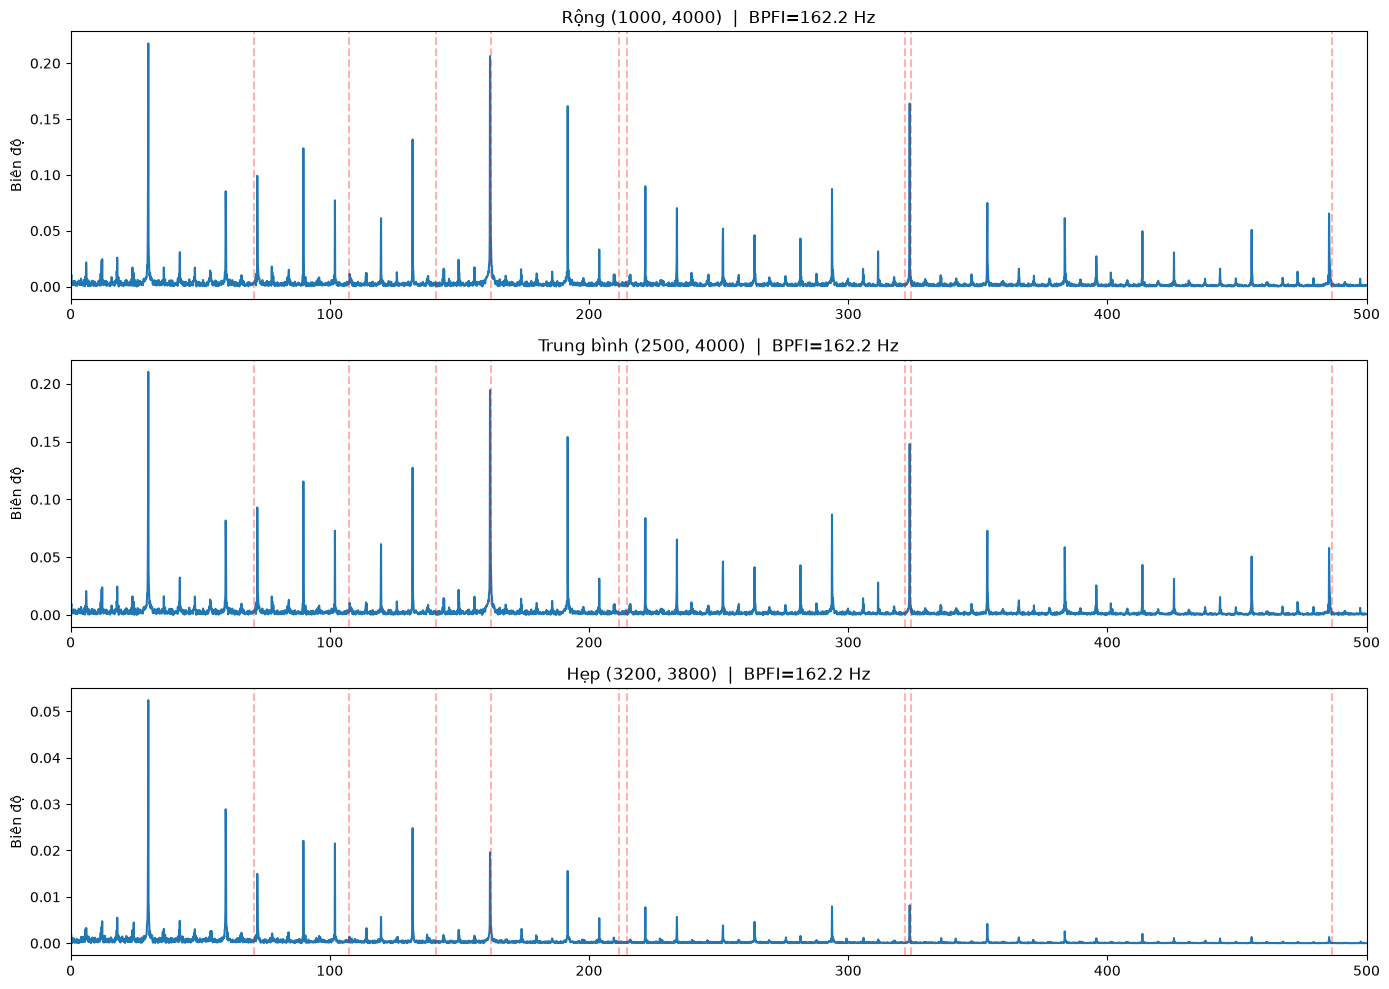

In [ ]:
# Test 3 dải bandpass — so sánh trực quan
BAND_CANDIDATES = {
    "Rộng (1000, 4000)": (1000, 4000),
    "Trung bình (2500, 4000)": (2300, 4000),
    "Hẹp (3200, 3800)": (3200, 3800),
}

# Test trên IR 21 mils (lỗi khó nhất để envelope bắt BPFI)
file_path = pick_file(manifest, label="IR", load_hp=0, diameter_mils=21)
x = load_de_signal(Path(file_path))

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, (name, band) in zip(axes, BAND_CANDIDATES.items()):
    env = square_law_envelope(x, fs, band=band, lp_cutoff=500)
    freqs_env, mag_env = compute_fft(env - env.mean(), fs)
    ax.plot(freqs_env, mag_env)
    for fault_name in ["BPFO", "BPFI", "BSF"]:
        for h in [1, 2, 3]:
            ax.axvline(fault_freqs[fault_name] * h, color='red', alpha=0.3, ls='--')
    ax.set_xlim(0, 500)
    ax.set_title(f"{name}  |  BPFI={fault_freqs['BPFI']:.1f} Hz")
    ax.set_ylabel("Biên độ")

plt.tight_layout()

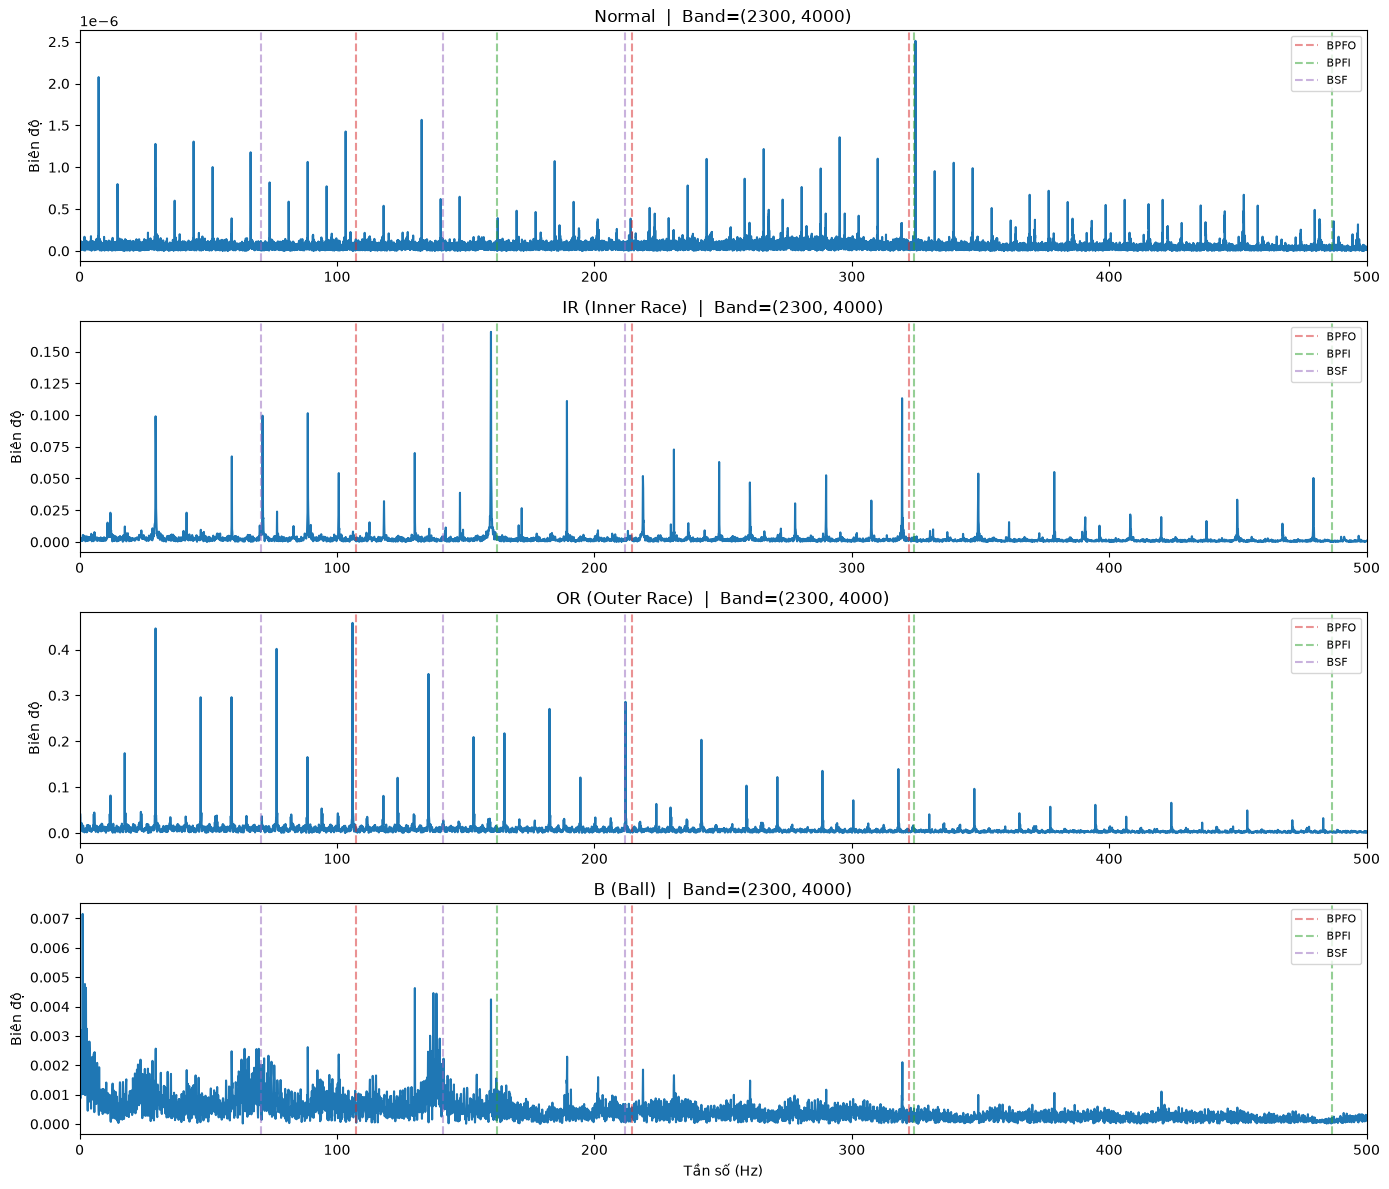

In [50]:
# Test 4 trường hợp: Normal, IR, OR, Ball — cùng tải 1HP
FAULT_CASES = {
    "Normal": dict(label="Normal"),
    "IR (Inner Race)": dict(label="IR", diameter_mils=21),
    "OR (Outer Race)": dict(label="OR", diameter_mils=21),
    "B (Ball)": dict(label="B", diameter_mils=21),
}

BAND = (2300, 4000)  # band đã chọn là hợp lý ở bước trước

FAULT_COLORS = {
    "BPFO": "tab:red",
    "BPFI": "tab:green",
    "BSF": "tab:purple",
}

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
for ax, (name, params) in zip(axes, FAULT_CASES.items()):
    file_path = pick_file(manifest, load_hp=1, **params)
    x = load_de_signal(Path(file_path))
    env = square_law_envelope(x, fs, band=BAND, lp_cutoff=500)
    freqs_env, mag_env = compute_fft(env - env.mean(), fs)

    ax.plot(freqs_env, mag_env)
    for fault_name in ["BPFO", "BPFI", "BSF"]:
        for h in [1, 2, 3]:
            ax.axvline(
                fault_freqs[fault_name] * h,
                color=FAULT_COLORS[fault_name],
                alpha=0.5,
                ls='--',
                label=fault_name if h == 1 else None,  # chỉ label lần đầu để tránh lặp legend
            )
    ax.set_xlim(0, 500)
    ax.set_title(f"{name}  |  Band={BAND}")
    ax.set_ylabel("Biên độ")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Tần số (Hz)")
plt.tight_layout()